## Linear Regression

### Visual Thinking

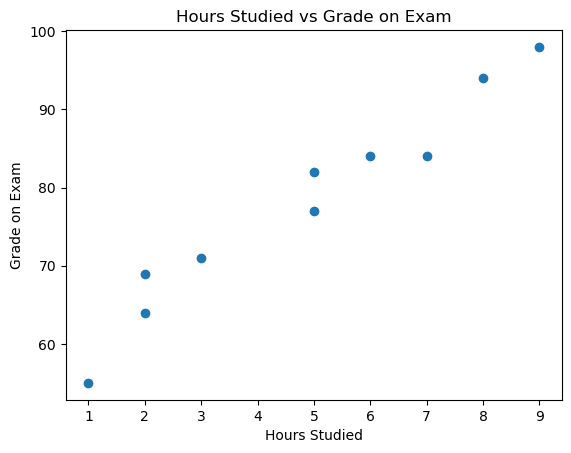

In [11]:
import numpy as np 
import matplotlib.pyplot as plt

hours = np.array([2, 9, 5, 5, 3, 7, 1, 8, 6, 2], dtype=float)
grades = np.array([69, 98, 82, 77, 71, 84, 55, 94, 84, 64], dtype=float)

plt.scatter(hours, grades)
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.title("Hours Studied vs Grade on Exam")
plt.show()

#### Python | Manual Calculation

In [12]:
x = hours
y = grades
x_mean = x.mean()
y_mean = y.mean()
 
beta1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print(f"Mean of X: {x_mean:.2f}")
print(f"Mean of Y: {y_mean:.2f}")
print(f"Intercept (β0): {beta0:.4f}")
print(f"Slope (β1): {beta1:.4f}")
print(f"Fitted line: y_hat = {beta0:.2f} + {beta1:.2f}x")


Mean of X: 4.80
Mean of Y: 77.80
Intercept (β0): 55.0355
Slope (β1): 4.7426
Fitted line: y_hat = 55.04 + 4.74x


In [13]:
new_hours = 4
predicted_grade = beta0 + beta1 * new_hours
print(f"Predicted grade for {new_hours} hours: {predicted_grade:.2f}")

Predicted grade for 4 hours: 74.01


#### Regression in Python scikit-learn

In [14]:
from sklearn.linear_model import LinearRegression

X = hours.reshape(-1, 1)
y = grades
hours_model = LinearRegression()
hours_model.fit(X, y)

print(f"Intercept: {hours_model.intercept_:.4f}")
print(f"Slope: {hours_model.coef_[0]:.4f}")

Intercept: 55.0355
Slope: 4.7426


#### Visualization

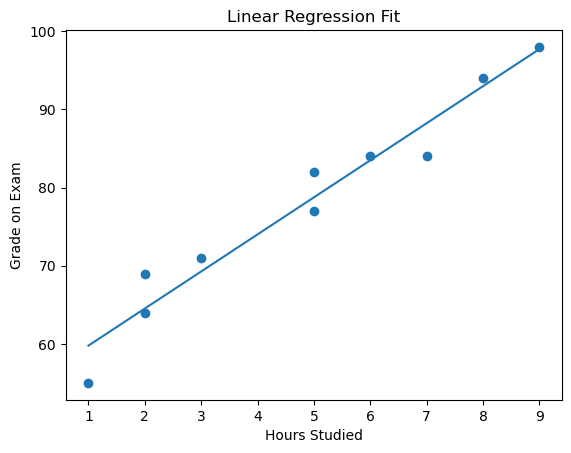

In [15]:
x_line = np.linspace(hours.min(), hours.max(), 100).reshape(-1, 1)
y_line = hours_model.predict(x_line)

plt.scatter(hours, grades)
plt.plot(x_line, y_line)
plt.title("Linear Regression Fit")
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.show()

#### Manual Calculation of $R^2$ and RMSE

In [16]:
y_pred = hours_model.predict(X)
residuals = y - y_pred

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)
rmse = np.sqrt(np.mean(residuals ** 2))

print(f"SS_res: {ss_res:.4f}")
print(f"SS_tot: {ss_tot:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

SS_res: 79.1213
SS_tot: 1599.6000
R-squared: 0.9505
RMSE: 2.8129


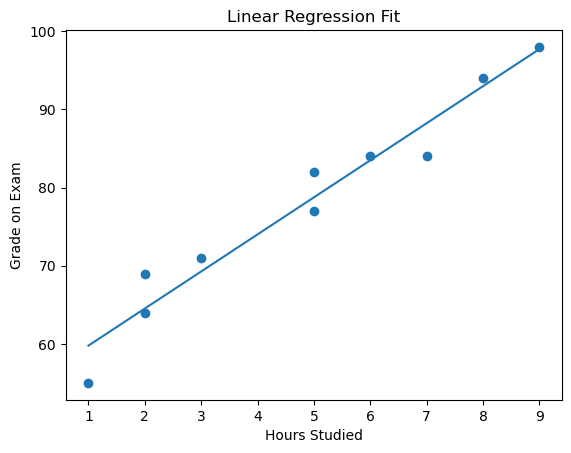

In [17]:
x_line = np.linspace(hours.min(), hours.max(), 100).reshape(-1, 1)
y_line = hours_model.predict(x_line)

plt.scatter(hours, grades)
plt.plot(x_line, y_line)
plt.title("Linear Regression Fit")
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.show()

#### Calculation with Scikit-learn

In [18]:
from sklearn.metrics import r2_score, mean_squared_error

r2_sklearn = r2_score(y, y_pred)
rmse_sklearn = np.sqrt(mean_squared_error(y, y_pred))

print(f"R-squared (sklearn): {r2_sklearn:.4f}")
print(f"RMSE (sklearn): {rmse_sklearn:.4f}")


R-squared (sklearn): 0.9505
RMSE (sklearn): 2.8129


### Business Applications

#### Example 1 | Marketing Spend $\rightarrow$ Sales

In [19]:
import pandas as pd
ads = pd.read_csv('../data/regression/advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [20]:
channel_results = []
for channel in ["tv", "radio", "social_media"]:
    X_channel = ads[[channel]]
    y_sales = ads["sales"]
    channel_model = LinearRegression()
    channel_model.fit(X_channel, y_sales)
    y_hat = channel_model.predict(X_channel)
    r2_channel = r2_score(y_sales, y_hat)
    rmse_channel = np.sqrt(mean_squared_error(y_sales, y_hat))
    channel_results.append({
        "channel": channel,
        "intercept": channel_model.intercept_,
        "slope": channel_model.coef_[0],
        "r_squared": r2_channel,
        "rmse": rmse_channel
    })
    
    pd.DataFrame(channel_results).round(4)

In [21]:
pd.DataFrame(channel_results).round(4)

,channel,intercept,slope,r_squared,rmse
0,tv,-132.4925,3.5615,0.9990,2948.5897
1,radio,40586.8007,8.3616,0.7545,46081.4060
2,social_media,118672.5717,22.1879,0.2782,79019.9030


In [22]:
ads[["tv", "radio", "social_media", "sales"]].corr().round(3)

,tv,radio,social_media,sales
tv,1.000,0.869,0.528,0.999
radio,0.869,1.000,0.606,0.869
social_media,0.528,0.606,1.000,0.527
sales,0.999,0.869,0.527,1.000


In [23]:
import plotly.express as px

corr = ads[["tv", "radio", "social_media", "sales"]].corr().round(3)
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
)
fig.update_layout(
    title="Correlation Matrix",
    xaxis_title="",
    yaxis_title=""
)
fig.show()

#### Multiple regression

In [24]:
X_multi_num = ads[["tv", "radio", "social_media"]]
y_sales = ads["sales"]

multi_num_model = LinearRegression()
multi_num_model.fit(X_multi_num, y_sales)
y_hat_multi_num = multi_num_model.predict(X_multi_num)

multi_num_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi_num.columns),
    "coefficient": [multi_num_model.intercept_] + list(multi_num_model.coef_)
}).round(4)

multi_num_r2 = r2_score(y_sales, y_hat_multi_num)
multi_num_rmse = np.sqrt(mean_squared_error(y_sales, y_hat_multi_num))

print(f"R-squared: {multi_num_r2:.4f}")
print(f"RMSE: {multi_num_rmse:.2f}")

R-squared: 0.9990
RMSE: 2948.54


In [25]:
multi_num_results

,feature,coefficient
0,intercept,-133.9630
1,tv,3.5626
2,radio,-0.0040
3,social_media,0.0050


In [26]:
ads["influencer"] = pd.Categorical(
    ads["influencer"],
    categories=["Mega", "Macro", "Micro", "Nano"]
)
X_multi = pd.get_dummies(
    ads[["tv", "radio", "social_media", "influencer"]],
    drop_first=True,
    dtype=int
)

multi_model = LinearRegression()
multi_model.fit(X_multi, y_sales)
y_hat_multi = multi_model.predict(X_multi)

multi_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi.columns),
    "coefficient": [multi_model.intercept_] + list(multi_model.coef_)
}).round(4)

multi_r2 = r2_score(y_sales, y_hat_multi)
multi_rmse = np.sqrt(mean_squared_error(y_sales, y_hat_multi))

print(f"R-squared: {multi_r2:.4f}")
print(f"RMSE: {multi_rmse:.2f}")


R-squared: 0.9990
RMSE: 2948.31


In [27]:
multi_results

,feature,coefficient
0,intercept,-91.7009
1,tv,3.5626
2,radio,-0.0039
3,social_media,0.0045
4,influencer_Macro,-11.6028
5,influencer_Micro,-68.4840
6,influencer_Nano,-85.5007


### Gold Prices

In [28]:
import pandas as pd
from os.path import join
PATH = '../data/regression/time_series'

ts = pd.read_csv(join(PATH, 'gold_prices_2022_2023.csv'), parse_dates=['Date'])
print(ts.shape)
ts.head()

(250, 5)


,Date,Open,High,Low,Close
0,2023-04-21,"2,016.10","2,016.80","1,982.30","1,990.50"
1,2023-04-20,"2,007.70","2,024.20","2,002.20","2,019.10"
2,2023-04-19,"2,017.90","2,020.30","1,980.90","2,007.30"
3,2023-04-18,"2,007.90","2,024.60","2,003.30","2,019.70"
4,2023-04-17,"2,014.10","2,028.00","1,993.40","2,007.00"


In [29]:
import glob
import os 
file_paths = glob.glob(join(PATH, "*.csv"))
file_paths

['../data/regression/time_series\\gold_prices_2022_2023.csv',
 '../data/regression/time_series\\gold_prices_2023_2024.csv',
 '../data/regression/time_series\\gold_prices_2024_2025.csv',
 '../data/regression/time_series\\gold_prices_2025_2026.csv']

In [30]:
file_names = [os.path.basename(file) for file in file_paths]
file_names

['gold_prices_2022_2023.csv',
 'gold_prices_2023_2024.csv',
 'gold_prices_2024_2025.csv',
 'gold_prices_2025_2026.csv']

In [31]:
dataframes = [pd.read_csv(file, parse_dates=['Date']) for file in file_paths]
ts_combined = pd.concat(dataframes, ignore_index=True)
print(ts_combined.shape)
ts_combined.tail()

(1008, 5)


,Date,Open,High,Low,Close
1003,2025-04-30,"3,324.50","3,337.60","3,275.60","3,319.10"
1004,2025-04-29,"3,354.90","3,359.30","3,309.20","3,333.60"
1005,2025-04-28,"3,336.50","3,363.80","3,278.00","3,347.70"
1006,2025-04-25,"3,362.00","3,384.10","3,274.80","3,298.40"
1007,2025-04-24,"3,301.80","3,377.00","3,301.30","3,348.60"


In [32]:
ts_combined.dtypes

Date     datetime64[us]
Open                str
High                str
Low                 str
Close               str
dtype: object

In [33]:
ts_combined["Close"] = (
    ts_combined["Close"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)
ts_combined["Close"] = pd.to_numeric(ts_combined["Close"], errors="coerce")

#### Vizualization

In [34]:
ts_combined = ts_combined.sort_values(by="Date")

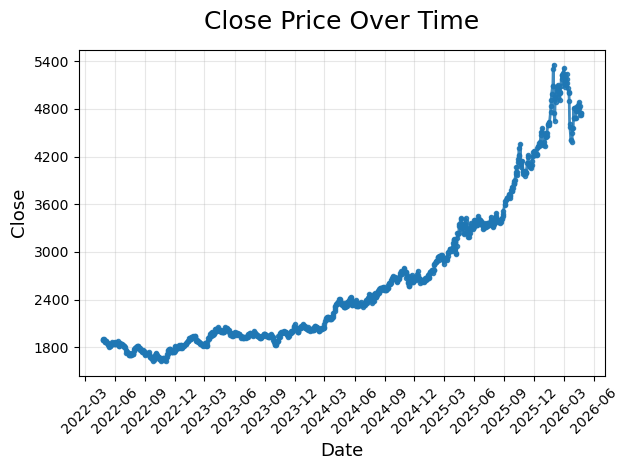

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

plt.plot(
    ts_combined["Date"],
    ts_combined["Close"],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85
)
plt.title("Close Price Over Time", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Close", fontsize=13)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Trend Analysis

In [36]:
ts_combined["time_index"] = np.arange(1, len(ts_combined) + 1)
X_time = ts_combined[["time_index"]]
y_time = ts_combined["Close"]

trend_model = LinearRegression()
trend_model.fit(X_time, y_time)
trend_pred = trend_model.predict(X_time)

trend_r2 = r2_score(y_time, trend_pred)
trend_rmse = np.sqrt(mean_squared_error(y_time, trend_pred))

In [37]:
print(f"Intercept: {trend_model.intercept_:.2f}")
print(f"Slope: {trend_model.coef_[0]:.4f}")
print(f"R-squared: {trend_r2:.4f}")
print(f"RMSE: {trend_rmse:.4f}")

Intercept: 1152.71
Slope: 2.9477
R-squared: 0.8247
RMSE: 395.4914


### ARIMA

In [42]:
from statsmodels.tsa.arima.model import ARIMA

ts_arima = ts_combined.set_index("Date").asfreq("B")
arima_model = ARIMA(ts_arima["Close"], order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=3)

In [39]:
arima_forecast

2026-04-27    4742.197623
2026-04-28    4742.974112
2026-04-29    4743.438758
Freq: B, Name: predicted_mean, dtype: float64

#### Prophet

In [43]:
from prophet import Prophet

df_prophet = ts_combined.rename(columns={"Date": "ds", "Close": "y"})
prophet_model = Prophet()
prophet_model.fit(df_prophet)

future = prophet_model.make_future_dataframe(periods=3, freq="B")
forecast = prophet_model.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

19:53:12 - cmdstanpy - INFO - Chain [1] start processing
19:53:13 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
1008,2026-04-27,5107.691003,4976.974659,5243.936018
1009,2026-04-28,5112.752760,4992.018247,5234.095490
1010,2026-04-29,5119.668046,4991.100525,5248.258940


#### Vizualization

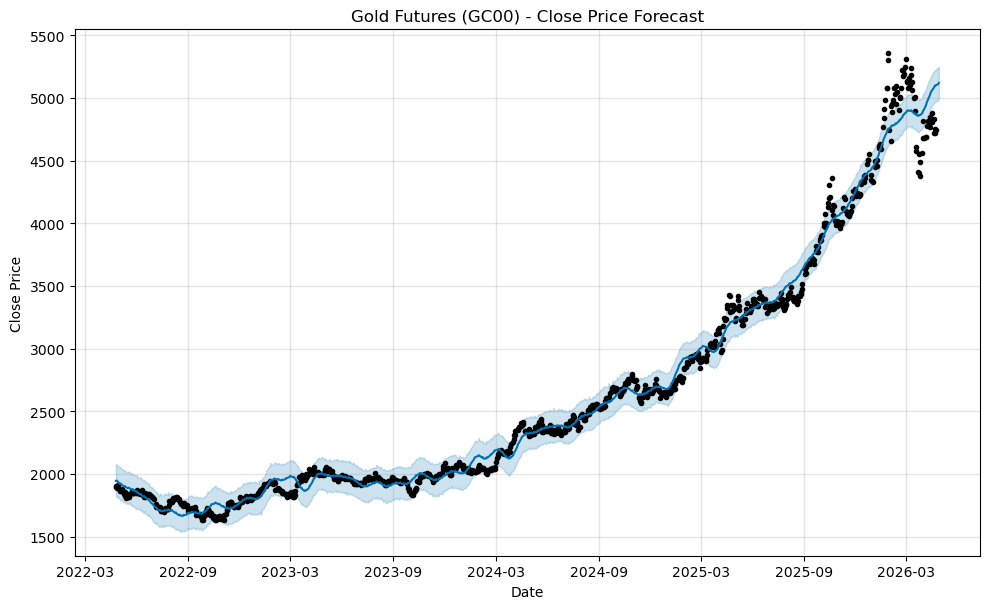

In [44]:
prophet_model.plot(forecast)
plt.title("Gold Futures (GC00) - Close Price Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

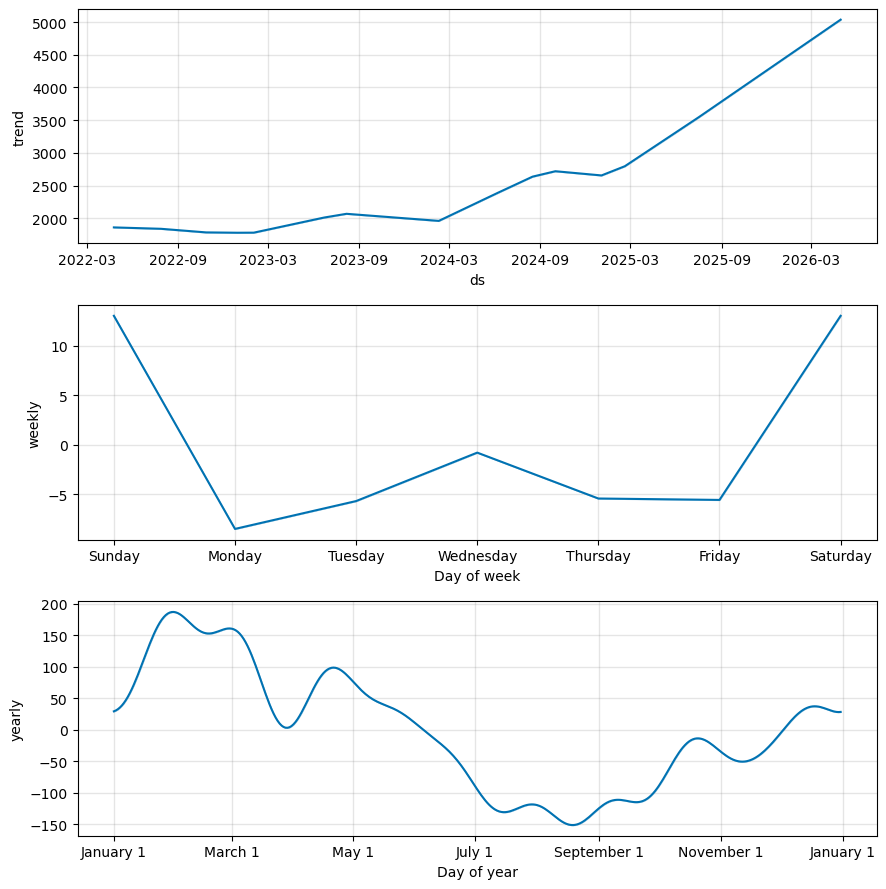

In [45]:
prophet_model.plot_components(forecast)
plt.show()

### Mini Homework

In [47]:
columns_to_clean = ["Open", "High", "Low", "Close"]

for col in columns_to_clean:
    ts_combined[col] = (
        ts_combined[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    
    ts_combined[col] = pd.to_numeric(ts_combined[col], errors="coerce")

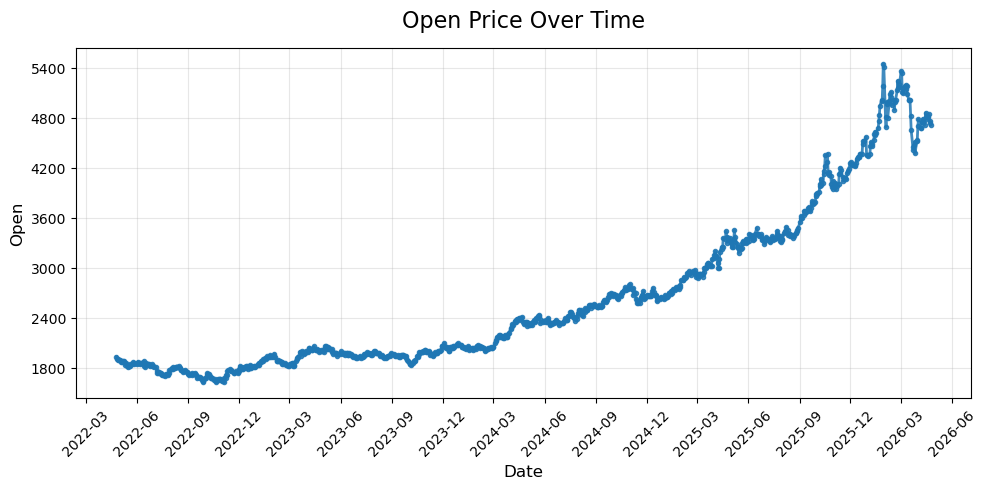

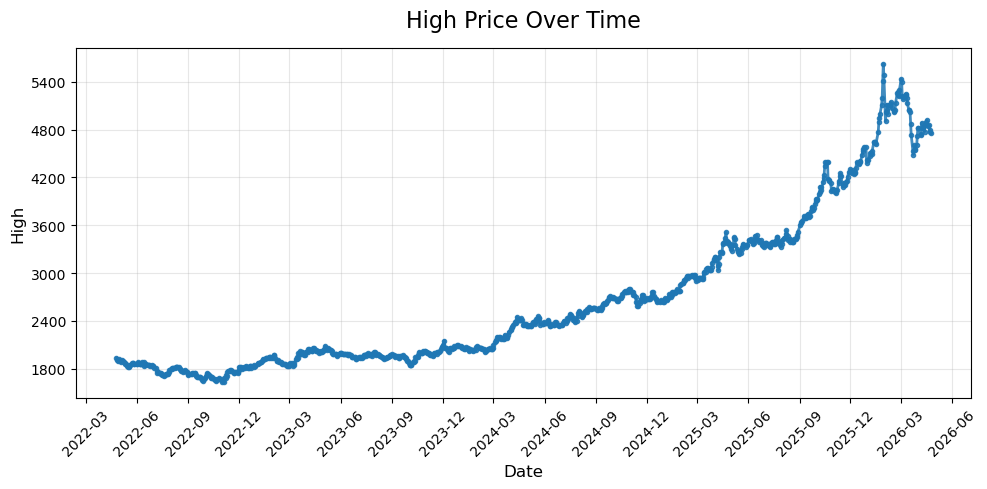

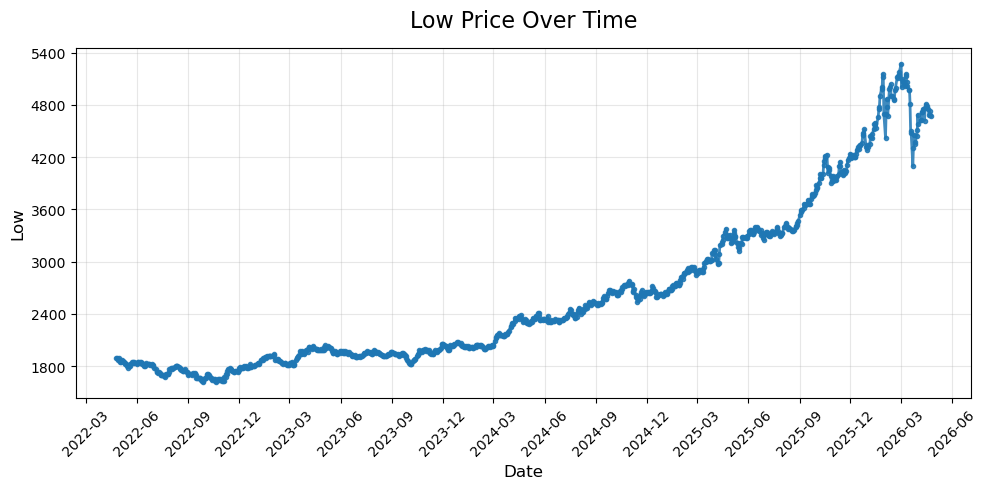

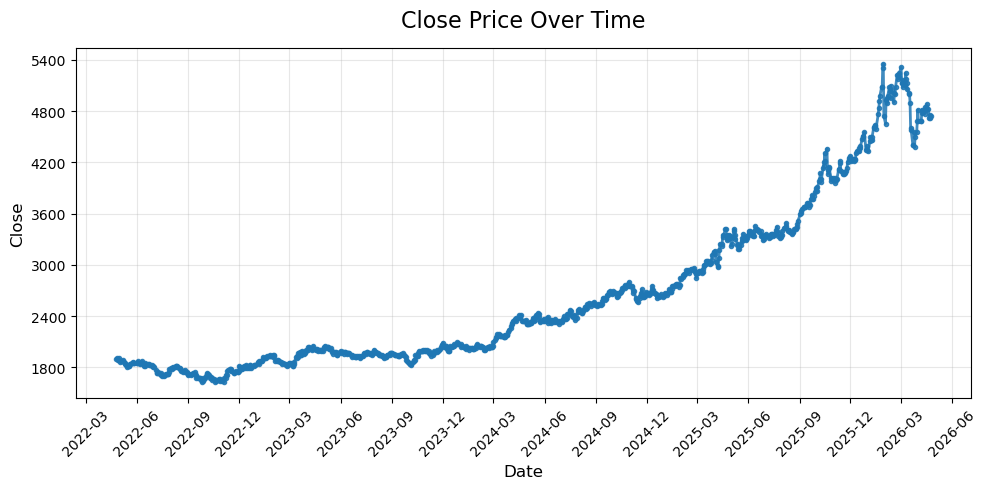

In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# Սյուների ցուցակը վիզուալիզացիայի համար
target_columns = ["Open", "High", "Low", "Close"]

for col in target_columns:
    plt.figure(figsize=(10, 5))
    plt.plot(
        ts_combined["Date"],
        ts_combined[col],
        linewidth=2,
        marker="o",
        markersize=3,
        alpha=0.85
    )
    
    # Գրաֆիկի ձևավորումն ըստ ընթացիկ սյան (col)
    plt.title(f"{col} Price Over Time", fontsize=16, pad=15)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel(col, fontsize=12)
    
    # X և Y առանցքների կարգավորումներ
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))
    
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Try to create a loop which will the exacltly thee same for Open, High, Low